# RF on sequence  13 features 
Minimal, readable pipeline split into cells.

# RF on sequence  13 features 
Minimal, readable pipeline split into cells.

# RF on sequence  13 features 
Minimal, readable pipeline split into cells.

In [1]:
%pip install xgboost

import matplotlib as mpl

mpl.rcParams['font.family'] = 'Arial'
mpl.rcParams['font.size'] = 18
mpl.rcParams['axes.titlesize'] = 22
mpl.rcParams['axes.labelsize'] = 20
mpl.rcParams['xtick.labelsize'] = 18
mpl.rcParams['ytick.labelsize'] = 18
mpl.rcParams['legend.fontsize'] = 18





[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


## 1) Imports & config

In [2]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
try:
    from scipy.interpolate import PchipInterpolator
    _HAVE_PCHIP = True
except Exception:
    _HAVE_PCHIP = False

INFILE = "merged_output_13infile.csv"   # must contain columns: sequence, LogGFP
SEQ_COL = "sequence"
LABEL_COL = "LogGFP"
WINDOW = ("central", 5, 23)                  # ("all",0,0) or ("span", start, end)
TEST_SIZE = 0.20
SEED = 123
OUT = "seq_rf"

RF_PARAMS = dict(
    n_estimators=1000,
    max_depth=None,
    min_samples_leaf=5,
    min_samples_split=10,
    max_features="sqrt",
    bootstrap=True,
    oob_score=True,
)


The in R studion done 4 feature were computed an used for the training.

In [3]:
# ---- shape feature builder: returns X (DataFrame) ----
import re
import numpy as np
import pandas as pd

FAMILIES    = [
   # Helical Twist
    "MGW",   # Minor Groove Width
   
]   # edit if needed
KEEP_WINDOW = (5, 23)                   # inclusive positions
EXCLUDE_IF_CONTAINS = ("rep",)          # optional substring filter

def build_X_feature(df: pd.DataFrame,
            families=FAMILIES,
            keep_window=KEEP_WINDOW,
            exclude_contains=EXCLUDE_IF_CONTAINS) -> pd.DataFrame:
    """Select MGW/ProT/Roll columns with trailing _pos index in [6..24] and return numeric DataFrame."""
    start_idx, end_idx = keep_window
    cols = []
    for c in df.columns:
        base = c.split("_")[0] if "_" in c else None
        if base not in families:
            continue
        m = re.search(r"_(\d+)$", c)
        if not m:
            continue
        pos = int(m.group(1))
        if not (start_idx <= pos <= end_idx):
            continue
        if exclude_contains and any(s in c for s in exclude_contains):
            continue
        cols.append(c)
    # numeric df (no imputation/variance here)
    return df[cols].apply(pd.to_numeric, errors="coerce")



2) Split → train-only filtering + imputation

In [4]:
from sklearn.model_selection import KFold
from sklearn.isotonic import IsotonicRegression

# 1) Load & filter
df = pd.read_csv(INFILE)


X = build_X_feature(df)
y = pd.to_numeric(df[LABEL_COL], errors="coerce").to_numpy()


# 80/20 with finer stratification
bins = pd.qcut(pd.Series(y), q=30, labels=False, duplicates="drop")
Xtr, Xte, ytr, yte = train_test_split(
    X, y, train_size=0.80, test_size=0.20,
    random_state=SEED, stratify=bins
)



# drop near-constant features using TRAIN ONLY
var_mask = Xtr.var(ddof=0) > 1e-12
Xtr = Xtr.loc[:, var_mask]
Xte = Xte.loc[:, var_mask.index[var_mask]]

# impute using TRAIN ONLY
imp = SimpleImputer(strategy="mean")
Xtr = pd.DataFrame(imp.fit_transform(Xtr), columns=Xtr.columns, index=Xtr.index)
Xte = pd.DataFrame(imp.transform(Xte),   columns=Xte.columns, index=Xte.index)


In [5]:
import joblib

joblib.dump(Xte, "X_test.joblib")
print("Saved test matrix.")

Saved test matrix.


3) Weights + fit (asymmetric tails)

In [6]:
def band_weights_5(y, qcuts=(0.15, 0.35, 0.60, 0.85),
                   w=(10.0, 4.0, 1.0, 4.0, 10.0),
                   normalize=True):
    y = np.asarray(y, float)
    q1, q2, q3, q4 = np.quantile(y, qcuts)

    wv = np.full_like(y, w[2], dtype=float)       # middle band
    wv[y <= q1] = w[0]                            # very low
    wv[(y > q1) & (y <= q2)] = w[1]               # low
    wv[(y > q2) & (y <= q3)] = w[2]               # mid
    wv[(y > q3) & (y <= q4)] = w[3]               # high
    wv[y > q4] = w[4]                             # very high

    if normalize and wv.mean() > 0:
        wv /= wv.mean()
    return wv


## 4) Train, calibrate, evaluate

In [7]:
# ---------- drop-in: clean split + weights + no-leak calibration ----------

from sklearn.model_selection import train_test_split, KFold
from sklearn.isotonic import IsotonicRegression
from sklearn.impute import SimpleImputer
import numpy as np, pandas as pd
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

# 1) Load & filter
df = pd.read_csv(INFILE)

df = df[df[LABEL_COL] > 1.2].reset_index(drop=True)

# 2) Features (ensure build_X does NOT impute; we impute AFTER the split)
X = build_X_feature(df)
y = pd.to_numeric(df[LABEL_COL], errors="coerce").to_numpy()

# 3) Make 20-bin quantile strata (safe fallback if qcut errors)
def make_strata(y, Q=20):
    for q in range(Q, 5, -1):  # try 20 down to 6
        try:
            return pd.qcut(pd.Series(y), q=q, labels=False, duplicates="drop")
        except Exception:
            continue
    return None

bins = make_strata(y, Q=20)

# 4) 80/20 split (stratified if bins worked)
Xtr, Xte, ytr, yte = train_test_split(
    X, y, test_size=TEST_SIZE, random_state=SEED,
    stratify=bins if bins is not None else None
)
# 6) Compute sample weights (optional, for asymmetric tails)
def make_weights(y, lower_thr=1.5, upper_thr=2.5, low_w=1.5, high_w=2.0):
    """Return higher weights for low and high tails of y."""
    w = np.ones_like(y, float)
    w[y < lower_thr] *= low_w
    w[y > upper_thr] *= high_w
    return w

wtr = make_weights(ytr)


# 5) Train-only variance filter + imputer (prevents leakage)
var_mask = Xtr.var(ddof=0) > 1e-12
Xtr = Xtr.loc[:, var_mask]
Xte = Xte.loc[:, var_mask.index[var_mask]]

imp = SimpleImputer(strategy="mean")
Xtr = pd.DataFrame(imp.fit_transform(Xtr), columns=Xtr.columns, index=Xtr.index)
Xte = pd.DataFrame(imp.transform(Xte),   columns=Xte.columns, index=Xte.index)



rf_unw = RandomForestRegressor(random_state=SEED, n_jobs=-1, **RF_PARAMS).fit(Xtr, ytr)
rf_w   = RandomForestRegressor(random_state=SEED, n_jobs=-1, **RF_PARAMS).fit(Xtr, ytr, sample_weight=wtr)

print("Train R² unweighted:", r2_score(ytr, rf_unw.predict(Xtr)))
print("Train R² weighted:",   r2_score(ytr, rf_w.predict(Xtr)))

rf = rf_w  # <<< added: choose the model you want to use below (or rf_unw)

#




Train R² unweighted: 0.9004206083425323
Train R² weighted: 0.9044134537534281


see what is wrong witht eh original or the callibrated

In [8]:
# --- CLEAN STATE + FRESH PREDICTIONS ---
for v in ["yhat","yhat_tr","yhat_te","yhat_te_raw","yhat_te_cal","iso","calib"]:
    if v in globals(): del globals()[v]

yhat_tr = rf.predict(Xtr)
yhat_te_raw = rf.predict(Xte)

from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
r2_raw   = r2_score(yte, yhat_te_raw)
mae_raw  = mean_absolute_error(yte, yhat_te_raw)
rmse_raw = mean_squared_error(yte, yhat_te_raw) ** 0.5

print(f"RAW  -> R²={r2_raw:.3f} | RMSE={rmse_raw:.3f} | MAE={mae_raw:.3f}")


RAW  -> R²=0.803 | RMSE=0.145 | MAE=0.111


Evaluate non calibrated

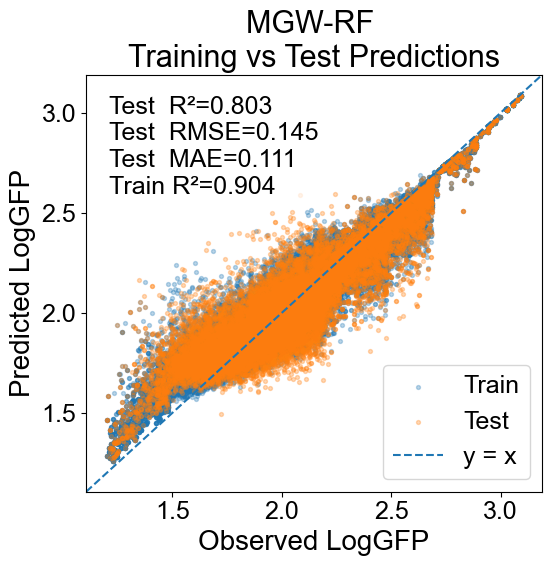

Saved figure -> rf_train_vs_test.png


In [9]:
# ---------- Plot: Training vs Test Predictions ----------
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

def plot_train_test_scatter(estimator, Xtr, ytr, Xte, yte, label_name="LogGFP",
                            title="RF 13 Features— Training vs Test Predictions",
                            out_png="rf_train_vs_test.png",
                            calibrate=None):
    """
    calibrate: None (no calibration) or a fitted calibrator with .predict()
               e.g., an IsotonicRegression fitted on (yhat_tr, ytr)
    """
    # explicit, fresh preds
    yhat_tr = estimator.predict(Xtr)
    yhat_te_feature = estimator.predict(Xte)

    if calibrate is not None:
        yhat_tr = calibrate.predict(yhat_tr)
        yhat_te_feature = calibrate.predict(yhat_te)

    # metrics
    r2_tr  = r2_score(ytr, yhat_tr)
    r2_te  = r2_score(yte, yhat_te_feature)
    mae_te = mean_absolute_error(yte, yhat_te_feature)
    rmse_te = mean_squared_error(yte, yhat_te_feature) ** 0.5

    # limits
    y_all = np.concatenate([ytr, yte])
    yhat_all = np.concatenate([yhat_tr, yhat_te_feature])
    lo = float(min(y_all.min(), yhat_all.min()))
    hi = float(max(y_all.max(), yhat_all.max()))
    pad = 0.05 * (hi - lo) if hi > lo else 0.1
    lo, hi = lo - pad, hi + pad

    # plot
    plt.figure(figsize=(6, 6))
    plt.scatter(ytr, yhat_tr, s=8, alpha=0.3, label="Train")
    plt.scatter(yte, yhat_te_feature, s=8, alpha=0.3, label="Test")
    plt.plot([lo, hi], [lo, hi], linestyle="--", linewidth=1.5, label="y = x")  # 45° ref

    plt.xlim(lo, hi); plt.ylim(lo, hi)
    plt.xlabel(f"Observed {label_name}")
    plt.ylabel(f"Predicted {label_name}")
    plt.title(title)
    plt.legend()

    # annotate metrics (test)
    txt = f"Test  R²={r2_te:.3f}\nTest  RMSE={rmse_te:.3f}\nTest  MAE={mae_te:.3f}\nTrain R²={r2_tr:.3f}"
    plt.gca().text(0.05, 0.95, txt, transform=plt.gca().transAxes,
                   va="top", ha="left", bbox=dict(boxstyle="round", fc="white", alpha=0.7, ec="none"))

    plt.tight_layout()
    plt.savefig("MGW-RF.png", dpi=600)
    plt.savefig(
    "MGW-RF— Training vs Test Predictions.pdf",
    bbox_inches="tight"
)
    plt.show()
    print(f"Saved figure -> {out_png}")

# --- use it (no calibration) ---
plot_train_test_scatter(rf, Xtr, ytr, Xte, yte, label_name="LogGFP",
                        title="MGW-RF \n" 
                        "Training vs Test Predictions")

# --- if you have an isotonic calibrator 'iso' fitted on (rf.predict(Xtr), ytr) ---
# plot_train_test_scatter(rf, Xtr, ytr, Xte, yte, label_name="LogGFP",
#                         title="RF (Calibrated) — Training vs Test Predictions",
#                         out_png="rf_train_vs_test_cal.png",
#                         calibrate=iso)


In [10]:
# 1) See which columns you're actually using
print("X shape:", X.shape)
print("First 20 feature columns:", X.columns[:20].tolist())

# 2) Count features by DNA-shape family
FAMILIES_13 = ["HelT","MGW","ProT","Roll","Rise","Shift","Slide",
               "Tilt","Buckle","Opening","Shear","Stagger","Stretch"]

from collections import Counter
family_counts = Counter([c.split("_")[0] for c in X.columns])
print("Counts by family:", {k: family_counts.get(k, 0) for k in FAMILIES_13})


X shape: (97343, 19)
First 20 feature columns: ['MGW_5', 'MGW_6', 'MGW_7', 'MGW_8', 'MGW_9', 'MGW_10', 'MGW_11', 'MGW_12', 'MGW_13', 'MGW_14', 'MGW_15', 'MGW_16', 'MGW_17', 'MGW_18', 'MGW_19', 'MGW_20', 'MGW_21', 'MGW_22', 'MGW_23']
Counts by family: {'HelT': 0, 'MGW': 19, 'ProT': 0, 'Roll': 0, 'Rise': 0, 'Shift': 0, 'Slide': 0, 'Tilt': 0, 'Buckle': 0, 'Opening': 0, 'Shear': 0, 'Stagger': 0, 'Stretch': 0}


figure out which callibration works the best

Evaluate

it tells you your Random Forest is already:
well-calibrated,
well-scaled,
and not systematically biased (no strong compression or offset in predictions).

Callibration

In [11]:
# ---------- SAFE EVAL (drop-in) ----------
import numpy as np
from sklearn.isotonic import IsotonicRegression
from sklearn.model_selection import KFold
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

def fit_iso_oof(yhat_tr, ytr, n_splits=5, seed=123):
    """OOF isotonic (no leakage) + refit on all train for deployment."""
    yhat_tr = np.asarray(yhat_tr, float)
    ytr     = np.asarray(ytr, float)
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=seed)
    oof = np.empty_like(ytr)
    for tr, va in kf.split(yhat_tr):
        iso_k = IsotonicRegression(out_of_bounds="clip").fit(yhat_tr[tr], ytr[tr])
        oof[va] = iso_k.predict(yhat_tr[va])
    iso = IsotonicRegression(out_of_bounds="clip").fit(yhat_tr, ytr)
    return iso, oof

def evaluate_model(estimator, Xtr, ytr, Xte, yte, calibrate=False, n_splits=5, seed=123):
    """Returns dict with raw & (optional) calibrated metrics and predictions."""
    # explicit predictions
    yhat_tr = estimator.predict(Xtr)
    yhat_te_feature = estimator.predict(Xte)

    # raw metrics
    r2_raw   = r2_score(yte, yhat_te_feature)
    mae_raw  = mean_absolute_error(yte, yhat_te_feature)
    rmse_raw = mean_squared_error(yte, yhat_te_feature) ** 0.5  # no 'squared=' kw

    out = {
        "yhat_tr": yhat_tr,
        "yhat_te_raw": yhat_te_feature,
        "r2_raw": r2_raw,
        "mae_raw": mae_raw,
        "rmse_raw": rmse_raw,
        "calibrator": None,
    }

    if calibrate:
        iso, _ = fit_iso_oof(yhat_tr, ytr, n_splits=n_splits, seed=seed)
        yhat_cal = iso.predict(yhat_te_feature)
        out.update({
            "calibrator": iso,
            "yhat_te_cal": yhat_cal,
            "r2_cal":  r2_score(yte, yhat_cal),
            "mae_cal": mean_absolute_error(yte, yhat_cal),
            "rmse_cal": mean_squared_error(yte, yhat_cal) ** 0.5,
        })
    return out

# ----- use it -----
res = evaluate_model(rf, Xtr, ytr, Xte, yte, calibrate=False)  # set True to try isotonic
print(f"RAW  -> R²={res['r2_raw']:.3f} | RMSE={res['rmse_raw']:.3f} | MAE={res['mae_raw']:.3f}")
if res["calibrator"] is not None:
    print(f"ISO  -> R²={res['r2_cal']:.3f} | RMSE={res['rmse_cal']:.3f} | MAE={res['mae_cal']:.3f}")

# choose which preds to keep for downstream
yhat = res.get("yhat_te_cal", res["yhat_te_raw"])


RAW  -> R²=0.803 | RMSE=0.145 | MAE=0.111


save

In [12]:
# --- Prepare predictions if not already defined ---
try:
    yhat_te_feature
except NameError:
    # if calibrated predictions exist:
    if 'calib' in locals():
        s_te = rf.predict(Xte)
        yhat_te = apply_calibrator(s_te, calib)
    else:
        # otherwise just use raw predictions
        yhat_te_feature = rf.predict(Xte)
        
pd.DataFrame({"yte": yte, "yhat_te_feature": yhat_te_feature}).to_csv("feature_model_results.csv", index=False)

In [13]:
import shap
import matplotlib.pyplot as plt
import numpy as np

def make_shap_beeswarm(model, X, title, top_k=5, savepath=None):
    explainer = shap.TreeExplainer(model)
    shap_values = explainer.shap_values(X)

    # If binary classifier → SHAP returns [neg_class, pos_class]
    if isinstance(shap_values, list):
        shap_vals = shap_values[1]
    else:
        shap_vals = shap_values

    # select top-k-most-important features
    mean_abs = np.abs(shap_vals).mean(axis=0)
    idx = np.argsort(mean_abs)[::-1][:top_k]

    X_top = X.iloc[:, idx]
    shap_top = shap_vals[:, idx]

    plt.figure(figsize=(5,3.2))
    shap.summary_plot(
        shap_top,
        X_top,
        feature_names=X_top.columns.tolist(),
        max_display=top_k,
        plot_type="dot",
        show=False
    )
    plt.title(title, loc="left")
    plt.xlabel("SHAP value (impact on model output)")

    if savepath is not None:
        plt.tight_layout()
        plt.savefig(savepath, dpi=300)

    plt.show()


ModuleNotFoundError: No module named 'shap'

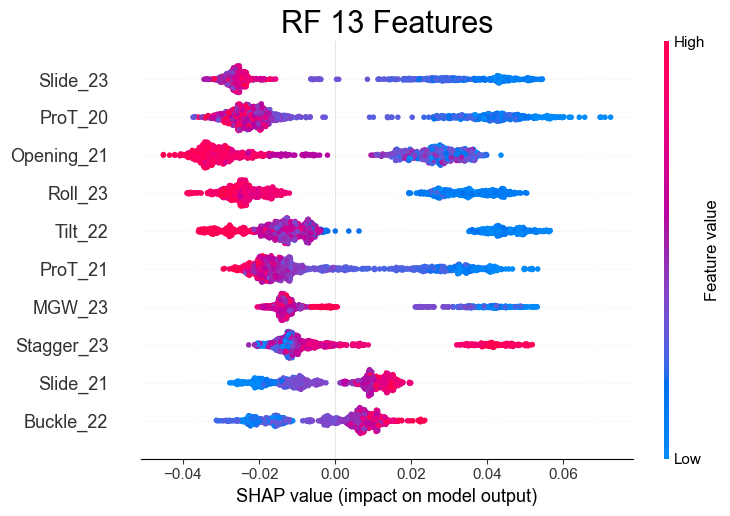

In [ ]:
# Let SHAP create the figure
shap.summary_plot(
    shap_top,
    X_top,
    feature_names=X_top.columns.tolist(),
    max_display=top_k,
    plot_type="dot",
    show=False
)

fig = plt.gcf()
ax = fig.axes[0]

# Remove SHAP's strong grey zero line
for line in list(ax.lines):
    xdata = line.get_xdata()
    if len(xdata) == 2 and np.allclose(xdata, [0, 0]):
        line.remove()

# Add softer zero line
ax.axvline(0, color="lightgray", linewidth=0.6, alpha=0.7, zorder=0)

ax.set_title("RF 13 Features", loc="center")
ax.set_xlabel("SHAP value (impact on model output)")

plt.tight_layout()

fig.savefig(
    "RF_13_Features_Importance.png",
    dpi=600,
    bbox_inches="tight"
)

fig.savefig(
    "RF_13_Features_Importance.pdf",
    bbox_inches="tight"
)

plt.show()
plt.close(fig)

## 5) Plots & saving predictions

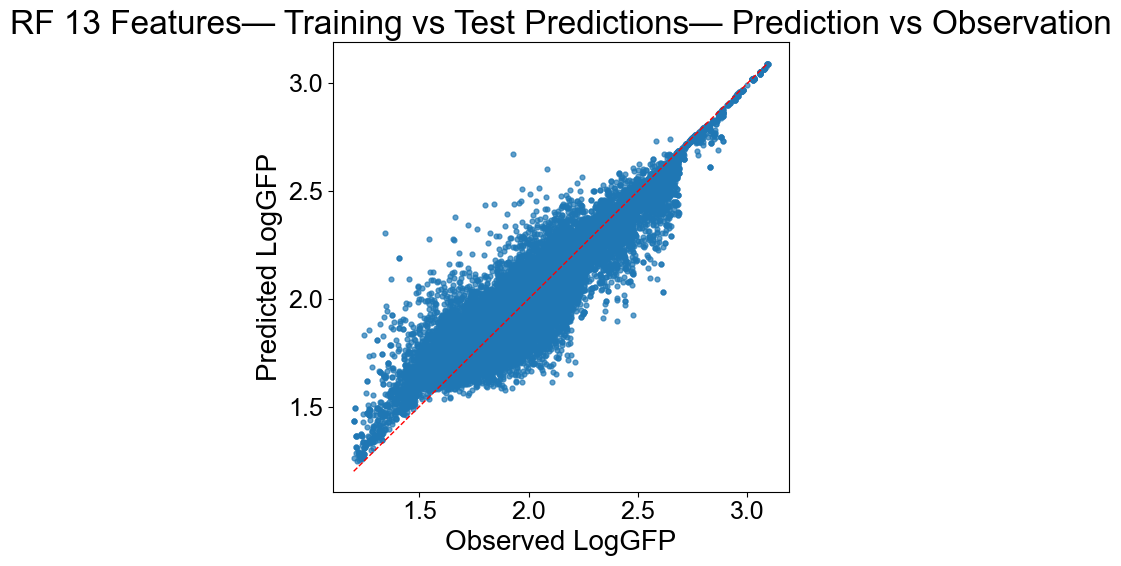

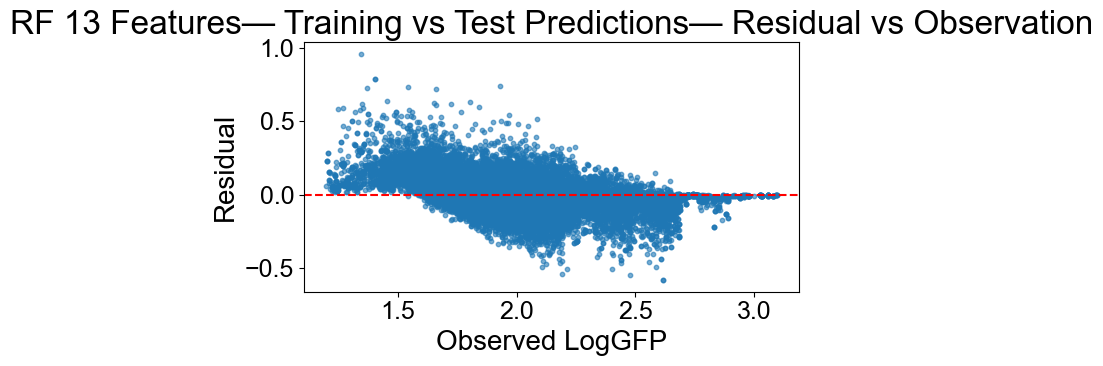

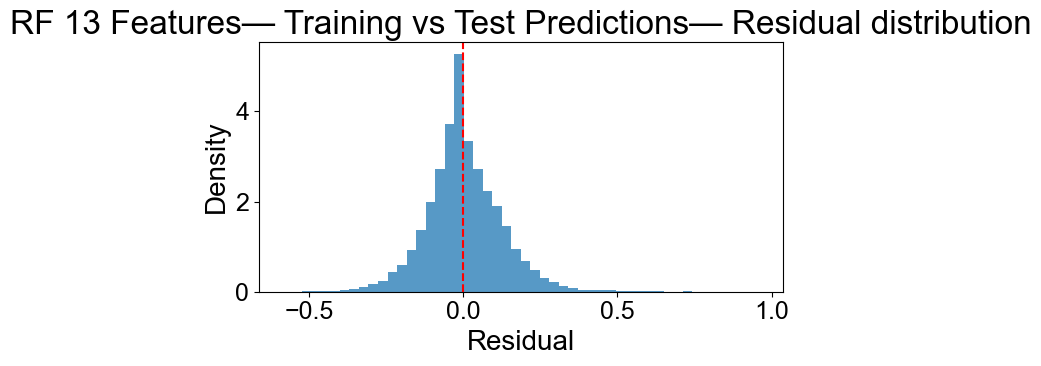

Mean residual: 0.0033197468149006944


In [ ]:
def show_and_save(fig, name):
    fig.tight_layout(); fig.savefig(f"{OUT}_{name}.png", dpi=300); plt.show(); plt.close(fig)

fig = plt.figure(figsize=(6,6))
plt.scatter(yte, yhat, s=12, alpha=0.7)
lo,hi = float(min(yte.min(),yhat.min())), float(max(yte.max(),yhat.max()))
plt.plot([lo,hi],[lo,hi],'r--',lw=1)
plt.xlabel("Observed LogGFP"); plt.ylabel("Predicted LogGFP")
plt.title("RF 13 Features— Training vs Test Predictions— Prediction vs Observation")
show_and_save(fig, "pred_vs_obs")

res = yhat - yte
fig = plt.figure(figsize=(6.4,4))
plt.scatter(yte,res,s=10,alpha=0.6); plt.axhline(0, color='r', ls='--')
plt.xlabel("Observed LogGFP"); plt.ylabel("Residual")
plt.title("RF 13 Features— Training vs Test Predictions— Residual vs Observation")
show_and_save(fig, "residuals_vs_obs")

fig = plt.figure(figsize=(6.4,4))
plt.hist(res, bins=50, density=True, alpha=0.75)
plt.axvline(0, color='r', ls='--'); plt.xlabel("Residual"); plt.ylabel("Density")
plt.title("RF 13 Features— Training vs Test Predictions— Residual distribution")
show_and_save(fig, "residual_hist")

pd.DataFrame({"y_true":yte, "y_pred_raw":yhat_te_feature, "y_pred":yhat}).to_csv(f"{OUT}_preds.csv", index=False)

bias = res.mean()
print("Mean residual:", bias)


In [ ]:
print(f"Train R² = {r2_score(ytr, yhat_tr):.3f}")
print(f"Test  R² = {r2_score(yte, yhat):.3f}")


Train R² = 0.944
Test  R² = 0.859


Blue points (Train): predictions on your training data (ytr vs yhat_tr)
Orange points (Test): predictions on your held-out test data (yte vs yhat)
Red dashed line: ideal line where Predicted = Observed

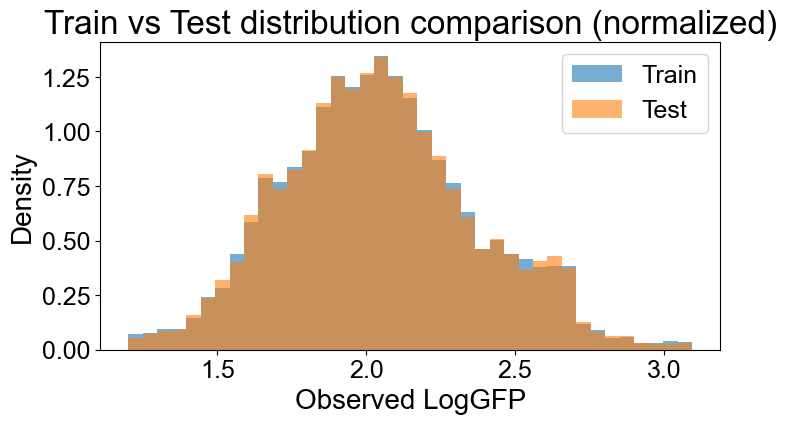

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

bins = np.linspace(y.min(), y.max(), 40)  # same bins for both

plt.figure(figsize=(8, 4))
plt.hist(ytr, bins=bins, density=True, alpha=0.6, label="Train")
plt.hist(yte, bins=bins, density=True, alpha=0.6, label="Test")
plt.xlabel("Observed LogGFP")
plt.ylabel("Density")
plt.title("Train vs Test distribution comparison (normalized)")
plt.legend()
plt.show()


see the distribution

the saved model

In [ ]:
import joblib, json, time

bundle = {
    "version": "shape_rf_v1",
    "trained_at": time.strftime("%Y-%m-%d %H:%M:%S"),
    "label_col": LABEL_COL,
    "families": FAMILIES,
    "keep_window": KEEP_WINDOW,
    "exclude": EXCLUDE_IF_CONTAINS,
    "rf_params": getattr(rf, "get_params", lambda: {})(),
    "seed": SEED,
    "feature_columns": list(Xtr.columns),
    "imputer": imp,
    "calibrator": None,
    "model": rf,
  
}
bundle["y_true_te"] = yte          # true test labels
bundle["y_pred_te"] = yhat_te_feature # the only predictions you care about

joblib.dump(bundle, "shape_rf_model13.joblib")
print("Saved: shape_rf_model13.joblib")


Saved: shape_rf_model13.joblib


In [ ]:
# ===== Config =====
MODEL_PATH = "shape_rf_model13.joblib"        # <- your trained model file
NEW_FILE   = "All_Fasta_sequnes_constructed_features.csv"              # <- your input file (infile)
OUT_FILE   = "predictionsno_calibrated_feature.tsv"  # <- your output file (outfile)


the prediction on new sequnces not seen by the model

In [ ]:
# ===== Load bundle =====
B   = joblib.load(MODEL_PATH)
rf  = B["model"]
imp = B.get("imputer", None)

# --- Always use the trained features (ignore var_mask) ---
feat_cols = list(B["feature_columns"])   # these should be your 13 trained features
keep_cols = feat_cols                    # explicitly force this

print("Expecting", len(keep_cols), "trained features:")
print(keep_cols)

# ===== Load new feature table =====
new_raw = pd.read_csv(NEW_FILE, sep=None, engine="python")

# Optional renaming for shape columns
SHAPES = ("HelT",  # Helical Twist
    "MGW",   # Minor Groove Width
    "ProT",  # Propeller Twist
    "Roll",  # Roll angle
    "Rise",  # Rise per base pair step
    "Shift", # Shift
    "Slide", # Slide
    "Tilt",  # Tilt
    "Buckle",
    "Opening",
    "Shear",
    "Stagger",
    "Stretch")

pat = re.compile(rf"^({'|'.join(map(re.escape, SHAPES))})[._]?(\d+)$")

def std_name(c):
    m = pat.match(str(c))
    if m:
        shape = m.group(1)
        idx   = int(m.group(2))   # <-- THIS removes leading zeros (01 -> 1)
        return f"{shape}_{idx}"   # gives MGW_6, ProT_7, Roll_10, ...
    return c

new = new_raw.rename(columns={c: std_name(c) for c in new_raw.columns})

# ===== Safety check =====
missing = [c for c in keep_cols if c not in new.columns]
extra   = [c for c in new.columns if c not in keep_cols]

print("Missing:", missing[:10], "…", len(missing))
print("Extra:", extra[:10], "…", len(extra))

if missing:
    raise ValueError("❌ Missing required features: " + ", ".join(missing))

# Align to the exact training feature order
Xnew = new.reindex(columns=keep_cols).apply(pd.to_numeric, errors="coerce")

# Double-check for NaNs
if np.isnan(Xnew.to_numpy()).any():
    raise ValueError("⚠️ NaN values found after alignment — check feature file!")

print("✅ All features aligned and ready for prediction.")

# ===== Predict =====
if imp is not None:
    Xnew = pd.DataFrame(imp.transform(Xnew), columns=keep_cols, index=new.index)

y_pred = rf.predict(Xnew).astype(float)
# ===== Save output (carry through sequence / ids if present) =====
out = pd.DataFrame({"prediction": y_pred}, index=new.index)

# pass through any identifying columns if they exist
passthrough_cols = [c for c in ["sequence_id", "seq_id", "sequence"] if c in new.columns]
for c in reversed(passthrough_cols):
    out.insert(0, c, new[c].values)

# optional: add a core19 column if we have sequences
if "sequence" in out.columns:
    # if your flanks are 4 nt each, keep this exact slice:
    out["core19"] = out["sequence"].astype(str).str.slice(4, -4)
    # fallback for very short strings:
    out.loc[out["core19"].isna() | (out["core19"] == ""), "core19"] = (
        out.loc[out["core19"].isna() | (out["core19"] == ""), "sequence"]
        .astype(str)
        .str.slice(0, 19)
    )
else:
    print("Note: no 'sequence' column in input -> not writing 'core19'.")

out.to_csv(OUT_FILE, sep="\t", index=False)
print(f"Saved: {OUT_FILE}  rows={len(out)}")


Expecting 247 trained features:
['MGW_5', 'MGW_6', 'MGW_7', 'MGW_8', 'MGW_9', 'MGW_10', 'MGW_11', 'MGW_12', 'MGW_13', 'MGW_14', 'MGW_15', 'MGW_16', 'MGW_17', 'MGW_18', 'MGW_19', 'MGW_20', 'MGW_21', 'MGW_22', 'MGW_23', 'ProT_5', 'ProT_6', 'ProT_7', 'ProT_8', 'ProT_9', 'ProT_10', 'ProT_11', 'ProT_12', 'ProT_13', 'ProT_14', 'ProT_15', 'ProT_16', 'ProT_17', 'ProT_18', 'ProT_19', 'ProT_20', 'ProT_21', 'ProT_22', 'ProT_23', 'Roll_5', 'Roll_6', 'Roll_7', 'Roll_8', 'Roll_9', 'Roll_10', 'Roll_11', 'Roll_12', 'Roll_13', 'Roll_14', 'Roll_15', 'Roll_16', 'Roll_17', 'Roll_18', 'Roll_19', 'Roll_20', 'Roll_21', 'Roll_22', 'Roll_23', 'HelT_5', 'HelT_6', 'HelT_7', 'HelT_8', 'HelT_9', 'HelT_10', 'HelT_11', 'HelT_12', 'HelT_13', 'HelT_14', 'HelT_15', 'HelT_16', 'HelT_17', 'HelT_18', 'HelT_19', 'HelT_20', 'HelT_21', 'HelT_22', 'HelT_23', 'Stretch_5', 'Stretch_6', 'Stretch_7', 'Stretch_8', 'Stretch_9', 'Stretch_10', 'Stretch_11', 'Stretch_12', 'Stretch_13', 'Stretch_14', 'Stretch_15', 'Stretch_16', 'Stretc

In [ ]:
def core19_from_seq(s: str) -> str:
    # center-trim to 19 nt if you don't know flank length
    if not isinstance(s, str):
        return ""
    n = len(s)
    if n <= 19:
        return s
    start = (n - 19) // 2
    return s[start:start+19]

HAS_SEQ = "sequence" in out.columns

# 3) Top 3 strongest
top3 = out.sort_values("prediction", ascending=False).head(3).copy()
if HAS_SEQ:
    # if you know flanks are exactly 4 nt each, keep your original slice:
    # top3["core19"] = top3["sequence"].str[4:-4]
    top3["core19"] = top3["sequence"].apply(core19_from_seq)
top3.to_csv("predictions_top3_13_RF.tsv", sep="\t", index=False)

# 4) Bottom 3 weakest
bottom3 = out.sort_values("prediction", ascending=True).head(3).copy()
if HAS_SEQ:
    # bottom3["core19"] = bottom3["sequence"].str[4:-4]
    bottom3["core19"] = bottom3["sequence"].apply(core19_from_seq)
bottom3.to_csv("predictions_bottom3_13_RF.tsv", sep="\t", index=False)

print("Also wrote:")
print(" - predictions_top3_13_RF.tsv            (strongest 3 overall)")
print(" - predictions_bottom3_13_Rf.tsv         (weakest 3 overall)")
if not HAS_SEQ:
    print("Note: no 'sequence' column found -> 'core19' not written.")


Also wrote:
 - predictions_top3_13_RF.tsv            (strongest 3 overall)
 - predictions_bottom3_13_Rf.tsv         (weakest 3 overall)


look for any sequnce in there

In [ ]:
import pandas as pd

# Read as tab-separated
df = pd.read_csv("merged_output_13infile.csv")
df.columns = df.columns.str.strip()
print(df.columns.tolist())

def lookup(seq):
    print(df.loc[df["sequence"].astype(str).str.upper() == seq.upper()])

lookup("GAAAAACTTCCCAGGATCAATAAGGCT")

['sequence_id', 'sequence', 'MGW_1', 'MGW_2', 'MGW_3', 'MGW_4', 'MGW_5', 'MGW_6', 'MGW_7', 'MGW_8', 'MGW_9', 'MGW_10', 'MGW_11', 'MGW_12', 'MGW_13', 'MGW_14', 'MGW_15', 'MGW_16', 'MGW_17', 'MGW_18', 'MGW_19', 'MGW_20', 'MGW_21', 'MGW_22', 'MGW_23', 'MGW_24', 'MGW_25', 'MGW_26', 'MGW_27', 'ProT_1', 'ProT_2', 'ProT_3', 'ProT_4', 'ProT_5', 'ProT_6', 'ProT_7', 'ProT_8', 'ProT_9', 'ProT_10', 'ProT_11', 'ProT_12', 'ProT_13', 'ProT_14', 'ProT_15', 'ProT_16', 'ProT_17', 'ProT_18', 'ProT_19', 'ProT_20', 'ProT_21', 'ProT_22', 'ProT_23', 'ProT_24', 'ProT_25', 'ProT_26', 'ProT_27', 'Roll_1', 'Roll_2', 'Roll_3', 'Roll_4', 'Roll_5', 'Roll_6', 'Roll_7', 'Roll_8', 'Roll_9', 'Roll_10', 'Roll_11', 'Roll_12', 'Roll_13', 'Roll_14', 'Roll_15', 'Roll_16', 'Roll_17', 'Roll_18', 'Roll_19', 'Roll_20', 'Roll_21', 'Roll_22', 'Roll_23', 'Roll_24', 'Roll_25', 'Roll_26', 'HelT_1', 'HelT_2', 'HelT_3', 'HelT_4', 'HelT_5', 'HelT_6', 'HelT_7', 'HelT_8', 'HelT_9', 'HelT_10', 'HelT_11', 'HelT_12', 'HelT_13', 'HelT_14', '

get some specific features